In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks
import pandas as pd
import time
from tqdm import tqdm

total_start = time.time()

sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python') # QP5 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP3 Lumerical API path
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')  #QP2 Lumerical API path

WORKDIR = Path().resolve()                  # auto: wherever the notebook lives
REPO_ROOT = WORKDIR.parents[1]             # still assumes scripts/MODE_bend_wg/ structure
os.chdir(WORKDIR)
print("Current working directory:", os.getcwd())

# --- Save directory ---
data_save_dir = REPO_ROOT / "results_data" / "Data_MODE_bend_wg"
data_save_dir.mkdir(parents=True, exist_ok=True)
print("Data will be saved to:", data_save_dir)

assert WORKDIR.exists(), "WORKDIR does not exist"
assert data_save_dir.exists(), "Data save dir not created"

Current working directory: D:\Ligentic_NU_1_TapeOut_April2026\scripts\MODE_bend_wg
Data will be saved to: D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_MODE_bend_wg


In [2]:
import lumapi as lm
# Ensure Lumerical MODE session starts correctly
try:
    f.redraw()  # Test if 'f' is already active
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()  
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()  

# Check if f is valid
if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session. Check your Lumerical")
                
LumFileName = 'MODE_Calculation.lms' # save .lms file
f.save(LumFileName)
# Clear existing elements
f.switchtolayout()
f.selectall()
f.delete()
f.switchtolayout()

Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [3]:
#------------------------------------------------------------
# PARAMETERS
#------------------------------------------------------------
results = []
N_modes = 12
LambdaStart    = 1525E-9
LambdaStop     = 1575E-9

Width          = 2000E-9
Height         = 800E-9
Radius         = 30E-6
Material       = "Si3N4 (Silicon Nitride) - Luke"

BackgroundMaterial = "SiO2 (Glass) - Palik"

In [4]:
#---------------------------------------------------------------
# Bend WG setup
#---------------------------------------------------------------

f.addrect()
f.set('x',0)
f.set('y',0)
f.set('x span', 0.25*Radius)
f.set('y span', Width)
f.set('z',0)
f.set('z span',Height)
f.set ('material', Material)

#---------------------------------------------------------------
# Mode solver 
#---------------------------------------------------------------

f.addfde()
f.set("solver type", "2D X Normal")
f.set("x",0)  # Aligned with the right ring
f.set("y", 0)  # Centered in Y
f.set("y span", 2 * Width)
f.set("z", 0)  # Centered in Z
f.set("z span", 2 * Width)
f.set("wavelength", (LambdaStart + LambdaStop) / 2)
f.set("background material", BackgroundMaterial)
f.set("bent waveguide", 1)
f.set("bend radius", Radius)
f.set("bend orientation", 0)

#---------------------------------------------------------------
# Run
#---------------------------------------------------------------
f.findmodes()


20.0

  mode1: neff=1.8552, ng=2.122, loss=0.000 dB/cm, TE%=1.00
  mode2: neff=1.8257, ng=2.161, loss=0.000 dB/cm, TE%=0.00
  mode3: neff=1.7481, ng=2.184, loss=0.000 dB/cm, TE%=1.00
  mode4: neff=1.7296, ng=2.200, loss=0.000 dB/cm, TE%=0.01
  mode5: neff=1.5897, ng=2.240, loss=0.000 dB/cm, TE%=0.98
  mode6: neff=1.5860, ng=2.290, loss=0.000 dB/cm, TE%=0.04
  mode7: neff=1.5319, ng=2.098, loss=0.000 dB/cm, TE%=0.99
  mode8: neff=1.4928, ng=1.895, loss=0.000 dB/cm, TE%=0.08
  mode9: neff=1.4786, ng=1.714, loss=0.000 dB/cm, TE%=0.93
  mode10: neff=1.4513, ng=1.759, loss=0.000 dB/cm, TE%=0.97
  mode11: neff=1.4385, ng=1.610, loss=0.000 dB/cm, TE%=0.04
  mode12: neff=1.4253, ng=1.721, loss=0.000 dB/cm, TE%=0.01

--- Mode Summary ---
 mode     neff       ng  loss_dB_cm  te_frac  aeff_um2
    1 1.855221 2.122448         0.0 0.999464  1.227985
    2 1.825749 2.160562         0.0 0.002643  1.446781
    3 1.748103 2.183720         0.0 0.997461  1.563287
    4 1.729564 2.200119         0.0 0.012398  1

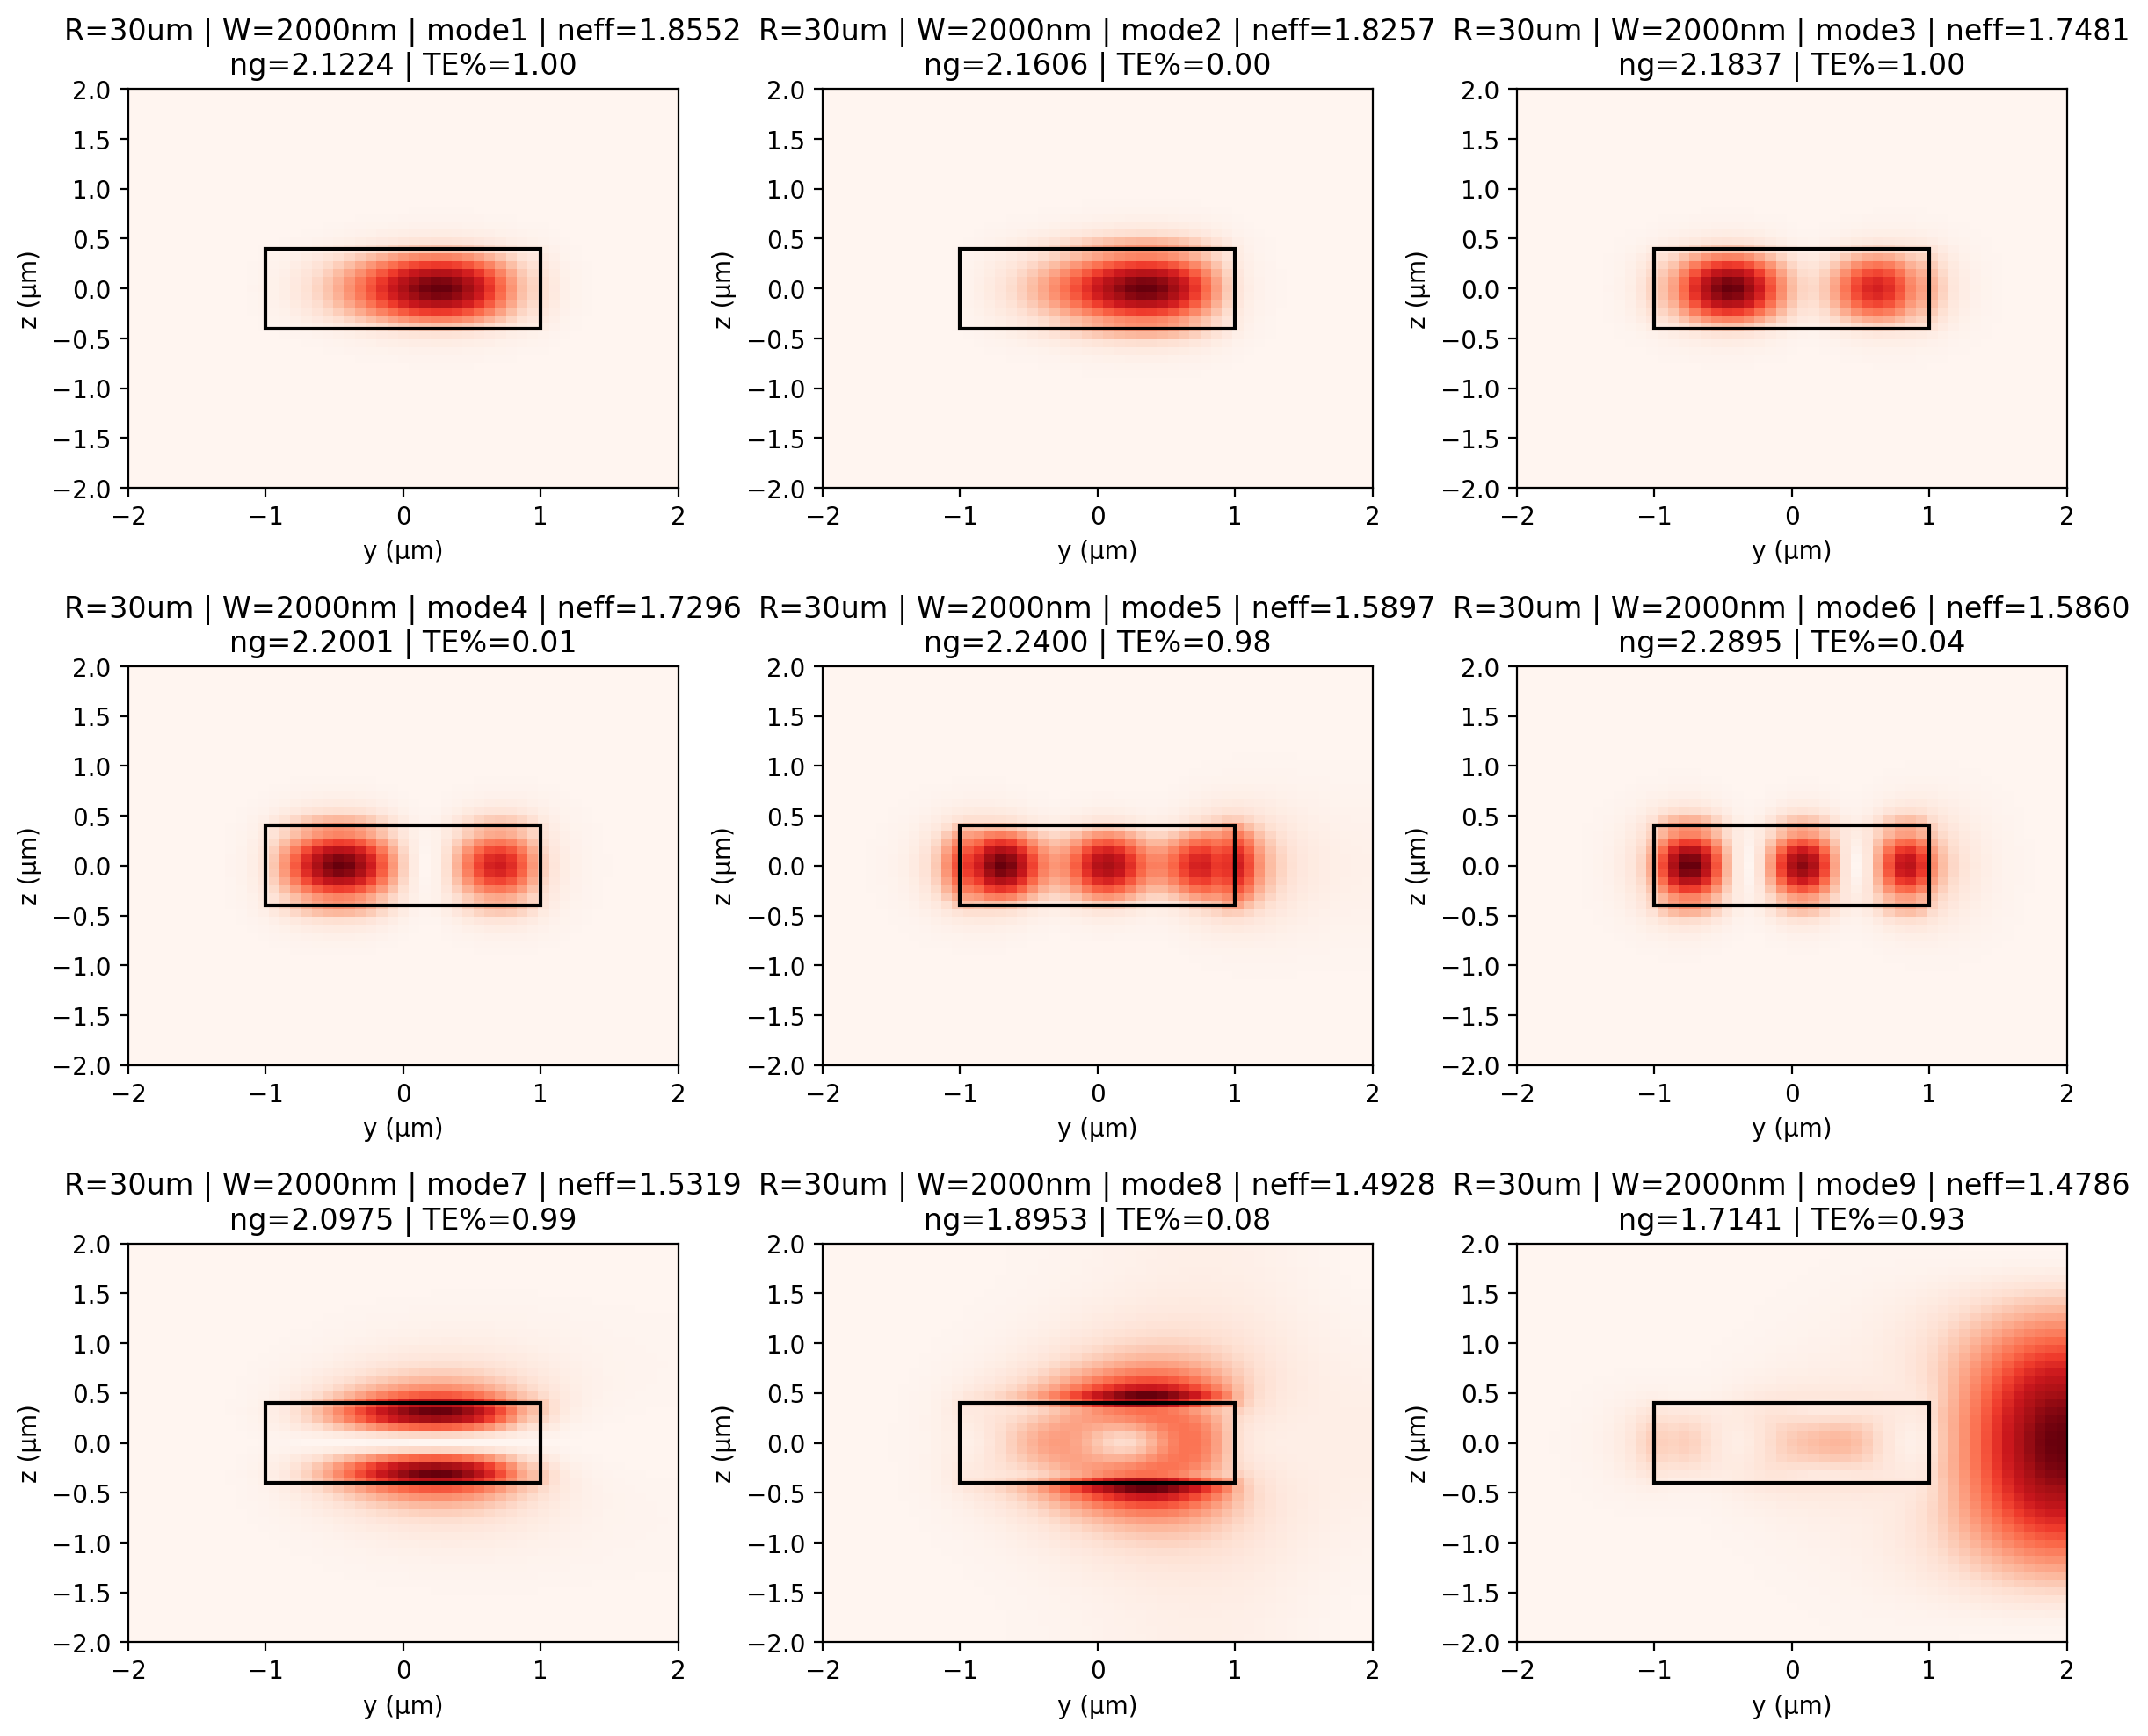

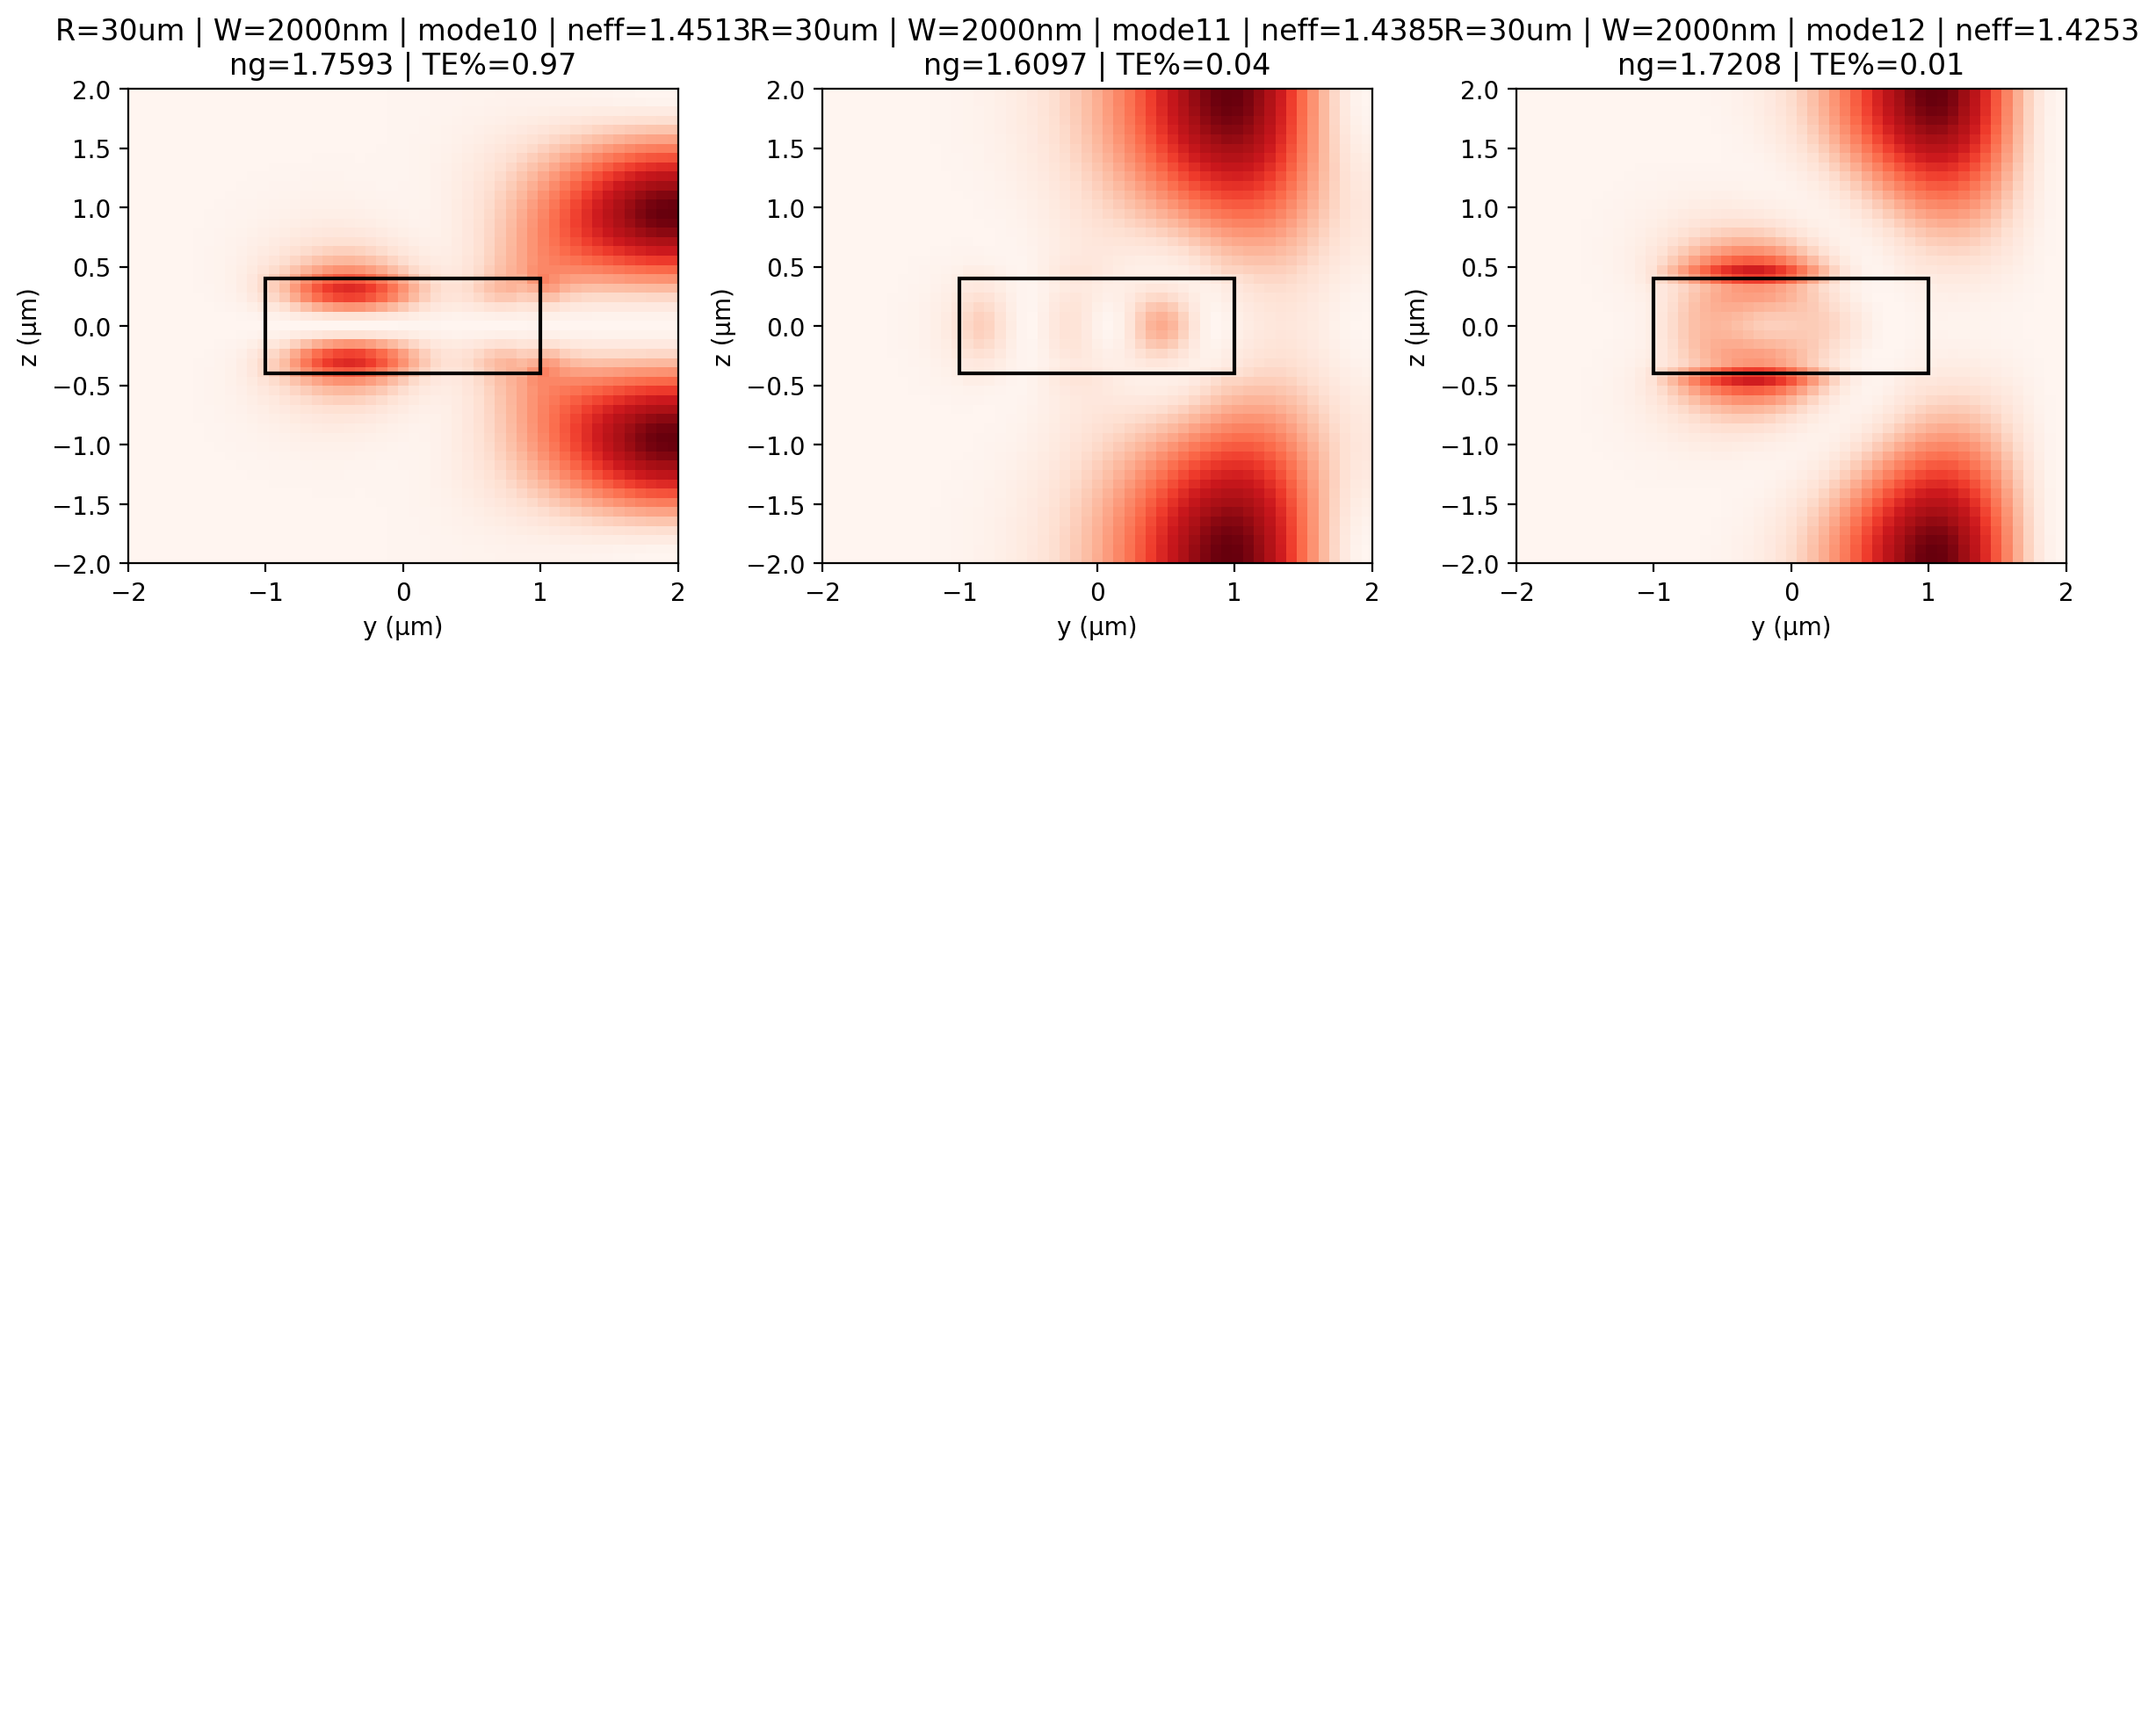

In [5]:
#---------------------------------------------------------------
# Extract data for first N modes
#---------------------------------------------------------------

for m in range(1, N_modes + 1):
    mode_label = f"FDE::data::mode{m}"
    try:
        neff = f.getdata(mode_label, "neff").flat[0]
    except Exception:
        print(f"  mode{m} not found — stopping at {m-1} modes.")
        break

    ng       = f.getdata(mode_label, "ng").flat[0]
    loss     = f.getdata(mode_label, "loss")
    te_frac  = f.getdata(mode_label, "TE polarization fraction")
    aeff     = f.getdata(mode_label, "mode effective area")

    Ex = np.squeeze(f.getdata(mode_label, "Ex"))
    Ey = np.squeeze(f.getdata(mode_label, "Ey"))
    Ez = np.squeeze(f.getdata(mode_label, "Ez"))

    results.append({
        'mode':       m,
        'width_nm':   Width * 1e9,
        'radius_um':  Radius * 1e6,
        'neff':       np.real(neff),
        'ng':         np.real(ng),
        'loss_dB_cm': np.real(loss) / 100,
        'te_frac':    np.real(te_frac),
        'aeff_um2':   np.real(aeff) * 1e12,
        'Ex': Ex,
        'Ey': Ey,
        'Ez': Ez
    })

    print(f"  mode{m}: neff={np.real(neff):.4f}, ng={np.real(ng):.3f}, "
        f"loss={np.real(loss)/100:.3f} dB/cm, TE%={np.real(te_frac):.2f}")

# %%
#---------------------------------------------------------------
# Summary table
#---------------------------------------------------------------

table_cols = ['mode', 'neff', 'ng', 'loss_dB_cm', 'te_frac', 'aeff_um2']
df = pd.DataFrame([{k: r[k] for k in table_cols} for r in results])
print("\n--- Mode Summary ---")
print(df.to_string(index=False))

# Save table
filename = f"ModeSummary_W{Width*1E6:.1f}um_H{Height*1E6:.1f}_{N_modes}modes.csv"
df.to_csv(data_save_dir / filename, index=False)
print(f"Table saved to {data_save_dir / filename}")

# %%
#---------------------------------------------------------------
# Plot mode profiles — 4 per figure
#---------------------------------------------------------------
from matplotlib.patches import Rectangle
# y_span = 2 * Width * 1E6
# z_span = y_span
# extent = [-y_span/2, y_span/2, -z_span/2, z_span/2]

MODES_PER_FIG = 9

for fig_idx in range(int(np.ceil(len(results) / MODES_PER_FIG))):
    batch = results[fig_idx * MODES_PER_FIG : (fig_idx + 1) * MODES_PER_FIG]
    n_ax  = len(batch)

    fig, axes = plt.subplots(3, 3, figsize=(12, 10), squeeze=False)
    for j in range(n_ax, 9): axes.flat[j].axis('off')
    axes = axes.flat

    for ax, r in zip(axes, batch):
        y_span = 2 * r['width_nm'] * 1e-3
        z_span = y_span
        extent = [-y_span/2, y_span/2, -z_span/2, z_span/2]

        E_total = np.abs(r['Ex'])**2 + np.abs(r['Ey'])**2 + np.abs(r['Ez'])**2
        E_norm  = E_total / E_total.max()

        ax.imshow(E_norm.T, origin='lower', cmap='Reds', aspect='auto', extent=extent)
        ax.add_patch(Rectangle(
            (-r['width_nm']*1e-3/2, -Height*1e6/2),
            r['width_nm']*1e-3, Height*1e6,
            linewidth=1.5, edgecolor='black', facecolor='none'
        ))
        ax.set_xlabel('y (µm)')
        ax.set_ylabel('z (µm)')
        ax.set_title(f"R={r['radius_um']:.0f}um | W={r['width_nm']:.0f}nm | mode{r['mode']} | neff={r['neff']:.4f}\n"
                    f"ng={r['ng']:.4f} | TE%={r['te_frac']:.2f}")

    fig.tight_layout()
    fig.set_dpi(200)
    plt.show()

